# **Deep Learning and Neural Networks**
# **Week 7 Lab - Transformers**

This lab will be about Natural Language Processing (NLP) tasks, which are the types of tasks Transformers were originally designed for. We will study other types of tasks that can be supported by Transformers next week!

In this lab, we will explore Transformer variants for different tasks using real-world datasets:
- **Task 1**: Coding scaled dot-product attention manually. This task has two questions.
- **Task 2**: Define and train a tiny Decoder-Only Transformer from scratch for a character-level next-token prediction task. This task has one question.
- **Task 3**: Sentiment Analysis with Transformers Encoder-Only Variant (BERT). This task has two sub-tasks and six questions.

 **Important: Using a free GPU on Google Colab will help improve the speed of execution of all tasks in this lab (especially task 3, where you have to fine-tune a model!). To use a GPU on Google Colab, go to "Runtime", then select "Change runtime type", select one of the available GPUs under "Hardware accelerator" (e.g. T4 GPU) and click "Save".**

## **General Instructions**
1. Read the explanatory text and run each code chunk sequentially.
2. Questions for each task appear throughout the notebook. Add your answers by following the specific instructions. Some questions require coding, while others require analysis based on one or more code outputs.
3. After answering all questions, submit your notebook through the corresponding QMPlus link for this lab assignment.

First, let's start by importing some required libraries and setting a fixed seed value in case we run random processes later on. In particular, for task 3 we will be using the Transformers library, the main Python library used for a variety of tasks. You can have a quick tour of the library at: https://huggingface.co/transformers/v3.3.1/quicktour.html.

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F #library for activation functions
from datasets import load_dataset
import math
import datasets
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

from transformers import (
    pipeline, #to create a sentiment analysis pipeline
    AutoTokenizer, #to load the tokenizer for the pre-trained model
    AutoModelForSequenceClassification, #to load the pre-trained model for sequence classification
    DataCollatorWithPadding, #to create a data collator that pads the input sequences to the same length
    Trainer, #to create a Trainer object that handles the training loop
    TrainingArguments, #to specify the training arguments for the Trainer
    logging #to set the logging level for the transformers library
)

from huggingface_hub.utils import disable_progress_bars #to disable the progress bars for the Hugging Face Hub (as we will using Hugging Face datasets and models))

torch.manual_seed(123) #Set a random seed for reproducibility


In [20]:
#We may need to install one of the libraries (evaluate library) if not yet installed
import importlib.util
import subprocess
import sys

package_name = "evaluate"

if importlib.util.find_spec(package_name) is None:
    print("'evaluate' not found. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    print("Installation complete.")
else:
    print("'evaluate' is already installed.")

import evaluate

'evaluate' is already installed.


### Task 1: Coding scaled dot-product attention manually

In this task, we will apply the attention calculation by Vaswani (2017) to a simple sentence: "the animal was tired so it rested". We will make attention interpretable by design, by:
- Crafting the features of each token/word in the sentence. We will use four features to characterise each word by: whether it is animate, whether it represents a state of "tiredness", whether it represents the act of motion, whether is a function word.
- Importantly, we will set Q=K=V required by out attention calculation to the same features we defined - so the attention scores will come directly from token similarity without learning any projections.

Before running the next cell, predict:
- Which two words should `animal` attend to the most?

In [21]:
#We have decided to use a dimension of 4: we will have four handcrafted features, and we want to represent in each: animate, tiredness, motion, function_word
tokens = ["the", "animal", "was", "tired", "so", "it", "rested"]
X = torch.tensor([
    [0.00, 0.00, 0.00, 1.00],  # the
    [1.00, 0.30, 0.20, 0.00],  # animal
    [0.10, 0.00, 0.00, 1.00],  # was
    [0.20, 1.00, 0.00, 0.00],  # tired
    [0.00, 0.00, 0.00, 1.00],  # so
    [1.00, 0.20, 0.00, 0.00],  # it
    [0.90, 0.70, 0.10, 0.00],  # rested
], dtype=torch.float32)

print("Input matrix shape: ", X.shape)

Q = X.clone() #Q will be the same as X (no transformation)
K = X.clone() #K will be the same as X (no transformation)
V = X.clone() #V will be the same as X (no transformation)
d_k = K.shape[1] #Number of dimensions of the key K

attn_scores = Q @ K.T #Calculate the attention values/scores doing matrix multiplication of queries and keys
attn_matrix = torch.softmax(attn_scores / math.sqrt(d_k), dim=-1) #Normalise dividing by dimension of keys, and then applying softmax

print("Attention matrix shape:", attn_matrix.shape)
print("Row sums (should all be 1):", attn_matrix.sum(dim=-1))

#Let's look at the attention scores/values of the word "animal"
it_idx = tokens.index("animal")
it_top2 = torch.topk(attn_matrix[it_idx], k=2)
print("\nTop-2 attended tokens for 'animal':")
for score, j in zip(it_top2.values.tolist(), it_top2.indices.tolist()):
    print(f"animal -> {tokens[j]} (weight={score:.3f})")

Input matrix shape:  torch.Size([7, 4])
Attention matrix shape: torch.Size([7, 7])
Row sums (should all be 1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

Top-2 attended tokens for 'animal':
animal -> animal (weight=0.184)
animal -> rested (weight=0.184)


**Task 1 - Question 1:** Explain the idea of the attention matrix, and what this means in this context for the query word "animal".

TODO - The attention matrix is a key component of the self-attention mechanism that powers Transformer architectures. It represents how much each token in a sequence should "attend to" or focus on every other token.

Concept of the Attention Matrix:
- The attention matrix has dimensions (sequence_length x sequence_length)
- Each row corresponds to a "query" token
- Each column corresponds to a "key" token
- The value at position (i, j) represents the attention weight that token i
  should place on token j
- Each row sums to 1, making the attention weights a probability distribution
  over all tokens

Context for the word "animal":
In this specific example, we have hand-crafted features for each word:
- animal: animate=1.0, tired=0.3, motion=0.2, function=0.0
- rested: animate=0.9, tired=0.7, motion=0.1, function=0.0
- it: animate=1.0, tired=0.2, motion=0.0, function=0.0

The attention scores show that "animal" attends most strongly to:
1. itself (weight=0.184) - maintaining its own identity
2. "rested" (weight=0.184) - because both words are animate, share similar
   characteristics, and have a grammatical relationship (subject-verb)
3. "it" (weight=0.178), very close behind - because it shares the same high
   animate feature as "animal" and is in fact the pronoun that refers back to
   "animal" later in the sentence

This demonstrates the core idea of self-attention: tokens update their
representations by aggregating information from other relevant tokens in the
sequence. "animal" incorporates information from "rested" and "it" to better
understand the sentence context, capturing both the subject-verb relationship
and this coreference-like link back to itself.

Now, we will visualise the attention scores for each word.

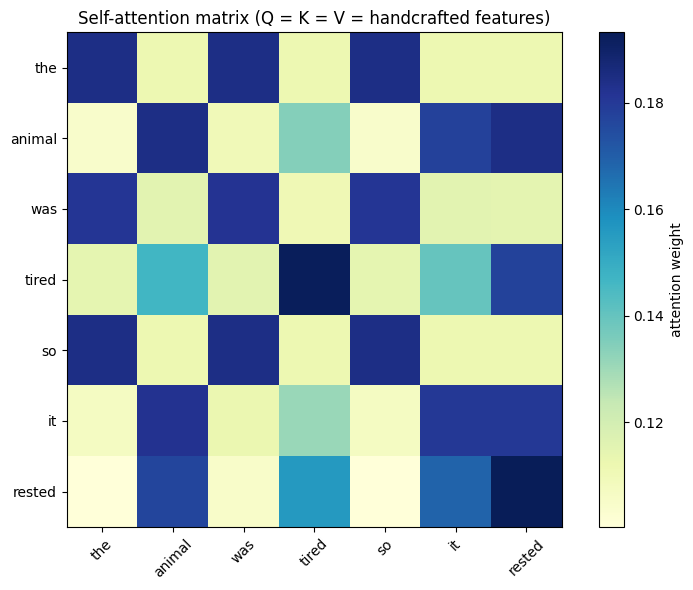

In [22]:
import matplotlib.pyplot as plt

# Visualize token-to-token attention
plt.figure(figsize=(8, 6))
plt.imshow(attn_matrix.detach().numpy(), cmap="YlGnBu")
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.yticks(range(len(tokens)), tokens)
plt.title("Self-attention matrix (Q = K = V = handcrafted features)")
plt.colorbar(label="attention weight")
plt.tight_layout()
plt.show()

**Task 1 - Question 2:** Look at the row for the word "rested" in the visualization above. What does this tell you about this word?

TODO - The row corresponding to **“rested”** shows that the token assigns the greatest attention to itself, helping preserve its own semantic information. It also assigns relatively high attention to **“animal”** and **“it.”** Both tokens have strong animate features and may represent the entity associated with the action of resting. A moderate amount of attention is also given to **“tired,”** reflecting the shared tiredness-related feature and the semantic relationship between being tired and becoming rested.

These attention patterns suggest that the mechanism is identifying meaningful relationships between the tokens based on their handcrafted feature similarities. In particular, it associates “rested” with possible animate participants and with a related physical state.

However, because the attention scores are produced from manually defined features rather than learned linguistic representations, the mechanism is not necessarily identifying grammatical roles directly. Instead, it captures an approximate subject–verb and state–verb relationship through similarities in the supplied feature vectors. This demonstrates how self-attention can connect contextually relevant tokens even without learned parameters, although the quality of those relationships depends strongly on the features chosen.

Finally, we will calculate the transformed version of our input matrix X by multiplying the attention matrix obtained previously with the original input.

In [23]:
X_transformed = torch.matmul(attn_matrix, X) #multiply attention by the original input
print("X transformed shape:", X_transformed.shape)
X_transformed

X transformed shape: torch.Size([7, 4])


tensor([[0.3649, 0.2459, 0.0335, 0.5529],
        [0.5657, 0.3542, 0.0553, 0.3194],
        [0.3744, 0.2489, 0.0346, 0.5437],
        [0.4960, 0.3884, 0.0471, 0.3440],
        [0.3649, 0.2459, 0.0335, 0.5529],
        [0.5617, 0.3476, 0.0544, 0.3268],
        [0.5609, 0.3778, 0.0546, 0.3057]])

## Task 2: Define and Train a Tiny Decoder-Only Transformer from Scratch

In this task, you will train a small decoder-only Transformer from scratch. You will use this to predict the next token in short text sequences. This task is intentionally designed small so training can finish quickly.

Let's define our data, which will be a very small corpus for language modeling - the task of predicting the next token.

In [24]:
corpus = """
transformers use attention to model long-range dependencies.
small models can still learn local structure from tiny datasets.
this lab trains a tiny transformer from scratch using pytorch.
""".strip().lower()

Let's define a vocabulary for our dataset - the mapping from characters to integer numbers that can be processed by our Transformer.

In [25]:
# Character-level vocabulary
chars = sorted(list(set(corpus))) # List of all unique characters in the corpus
stoi = {ch: i for i, ch in enumerate(chars)} # String to integer mapping
itos = {i: ch for ch, i in stoi.items()} # Integer to string mapping (for printing later on)
encode = lambda s: [stoi[c] for c in s] # Convert string to list of integers (to encode)
decode = lambda ids: "".join([itos[i] for i in ids]) # Convert list of integers to string (to decode)

data = torch.tensor(encode(corpus), dtype=torch.long) # Convert the entire corpus to a tensor of integers
data

tensor([20, 18,  4, 15, 19,  9, 16, 18, 14,  8, 18, 19,  1, 21, 19,  8,  1,  4,
        20, 20,  8, 15, 20, 12, 16, 15,  1, 20, 16,  1, 14, 16,  7,  8, 13,  1,
        13, 16, 15, 10,  2, 18,  4, 15, 10,  8,  1,  7,  8, 17,  8, 15,  7,  8,
        15,  6, 12,  8, 19,  3,  0, 19, 14,  4, 13, 13,  1, 14, 16,  7,  8, 13,
        19,  1,  6,  4, 15,  1, 19, 20, 12, 13, 13,  1, 13,  8,  4, 18, 15,  1,
        13, 16,  6,  4, 13,  1, 19, 20, 18, 21,  6, 20, 21, 18,  8,  1,  9, 18,
        16, 14,  1, 20, 12, 15, 22,  1,  7,  4, 20,  4, 19,  8, 20, 19,  3,  0,
        20, 11, 12, 19,  1, 13,  4,  5,  1, 20, 18,  4, 12, 15, 19,  1,  4,  1,
        20, 12, 15, 22,  1, 20, 18,  4, 15, 19,  9, 16, 18, 14,  8, 18,  1,  9,
        18, 16, 14,  1, 19,  6, 18,  4, 20,  6, 11,  1, 21, 19, 12, 15, 10,  1,
        17, 22, 20, 16, 18,  6, 11,  3])

Let's define our small Transformer model.

In [26]:
class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_heads, ff_dim, n_layers, block_size, dropout):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim) #Input embedding layer
        self.pos_emb = nn.Embedding(block_size, embed_dim) #Positional embedding layer

        # To implement decoder architectures using Pytorch, we use encoder-layer blocks, but run them with masking to produce decoder-only behavior (i.e. looking just into the past and not the future).
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, #embedding dimension of the model
            nhead=n_heads, #number of attention heads in the multihead attention mechanism
            dim_feedforward=ff_dim, #dimension of the feedforward network model
            dropout=dropout, #dropout probability for the feedforward network and attention layers - see the definition of the dropout layer in the PyTorch documentation: https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html
            activation="gelu", #See the definition of the GeLU activation function in the PyTorch documentation: https://pytorch.org/docs/stable/generated/torch.nn.GELU.html
            batch_first=True, #Whether the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature). If True, then the input and output tensors are expected to have shape (batch_size, seq_length, embedding_dim). If False, then the input and output tensors are expected to have shape (seq_length, batch_size, embedding_dim).
            norm_first=True, #Whether to perform layer normalization before or after the attention and feedforward layers. If True, then layer normalization is applied before the attention and feedforward layers. If False, then layer normalization is applied after the attention and feedforward layers.
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=n_layers) #Construct as many encoder blocks as given by the hyperparameter
        self.ln_f = nn.LayerNorm(embed_dim) #Final layer normalization after the last encoder block
        self.head = nn.Linear(embed_dim, vocab_size) #Final linear layer to project the output of the transformer to the vocabulary size for token prediction

        self.block_size = block_size #Maximum sequence length that the model can handle. This is used to create the positional embeddings and to ensure that the input sequences do not exceed this length.

    def forward(self, idx, targets=None):
        B, T = idx.shape #B = batch size, T = sequence length
        positions = torch.arange(T, device=idx.device) #Create a tensor of positions for each token in the sequence, ranging from 0 to T-1

        x = self.token_emb(idx) + self.pos_emb(positions)[None, :, :] #Add token embeddings and positional embeddings to the input indices to create the input representation for the transformer model

        #A causal mask prevents attention to future tokens (decoder-style)
        causal_mask = torch.triu(torch.ones(T, T, device=idx.device), diagonal=1).bool() #Create a causal mask to prevent the model from attending to future tokens in the sequence. The mask is an upper triangular matrix with ones above the diagonal, indicating that those positions should be masked (not attended to) during the attention computation.
        x = self.blocks(x, mask=causal_mask) #Pass the input representation through the transformer encoder blocks, applying the causal mask to ensure that each token can only attend to itself and previous tokens in the sequence.
        x = self.ln_f(x) #Apply layer normalization to the output of the transformer blocks to stabilize training and improve convergence
        logits = self.head(x) #Project the output of the transformer to the vocabulary size to obtain logits for each token in the sequence

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T)) #Compute cross-entropy loss between predicted logits and target tokens

        return logits, loss

Let's instantiate our model including hyperparameters.

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"
block_size = 32 # Maximum sequence length
batch_size = 16 #We will train on batches of 16 sequences at a time
embed_dim = 64 #Embedding dimension
n_heads = 4 # Number of attention heads h
ff_dim = 128 #Feed-forward layer dimension
n_layers = 2 #Number of transformer blocks
dropout = 0.1 #Dropout is a regularization technique that randomly sets a fraction of the input units to 0 at each update during training time, which helps prevent overfitting.
learning_rate = 3e-3 #Learning rate is a hyperparameter that controls how much to change the model in response to the estimated error each time the model weights are updated.
max_steps = 400 # Maximum number of training steps

model = TinyTransformerLM(
    vocab_size=len(chars),
    embed_dim=embed_dim,
    n_heads=n_heads,
    ff_dim=ff_dim,
    n_layers=n_layers,
    block_size=block_size,
    dropout=dropout,
).to(device)

/tmp/ipykernel_519/4125979638.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=n_layers) #Construct as many encoder blocks as given by the hyperparameter


Let's apply our training procedure.

In [28]:
# Function to get a batch of data
def get_batch(split_data, batch_size=batch_size, block_size=block_size):
    idx = torch.randint(0, len(split_data) - block_size - 1, (batch_size,))
    x = torch.stack([split_data[i : i + block_size] for i in idx])
    y = torch.stack([split_data[i + 1 : i + block_size + 1] for i in idx])
    return x.to(device), y.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Train/validation split
n = int(0.8 * len(data))
train_data, val_data = data[:n], data[n:]

# Track losses for plotting later on
train_losses, val_losses, eval_steps = [], [], []

for step in range(max_steps):
    model.train() #Put model in training mode
    xb, yb = get_batch(train_data) #Get data
    _, loss = model(xb, yb) #Compute loss (forward pass)

    optimizer.zero_grad() #Clear gradients before backward pass
    loss.backward() #Compute gradients (backward pass)
    optimizer.step() #Update model parameters (weights) using the optimizer

    #Evaluate on validation set
    if step % 100 == 0 or step == max_steps - 1:
        model.eval() #Put model in evaluation mode
        with torch.no_grad():
            xval, yval = get_batch(val_data if len(val_data) > block_size + 1 else train_data) #Get a batch of validation data
            _, val_loss = model(xval, yval) #Compute validation loss (forward pass without gradient computation)

        # Store losses for plotting
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        eval_steps.append(step)

        print(f"step {step:>3d} | train_loss={loss.item():.4f} | val_loss={val_loss.item():.4f}")



step   0 | train_loss=3.2894 | val_loss=3.3724
step 100 | train_loss=0.4692 | val_loss=4.3167
step 200 | train_loss=0.1690 | val_loss=5.3343
step 300 | train_loss=0.1478 | val_loss=5.9368
step 399 | train_loss=0.1008 | val_loss=6.2486


Let's define an evaluation function which will receive one or more input tokens (prompt) and return the next tokens up to max_new_tokens.

In [29]:
@torch.no_grad() #Disable gradient calculation for prediction/inference
def generate(model, prompt, max_new_tokens=120):
    model.eval() #Put model in evaluation mode
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device) # Initialize the input sequence by passing the prompt to the model and encoding the prompt into a tensor of integers

    #Generate new tokens one at a time
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:] # Ensure the input sequence does not exceed the model's block size
        logits, _ = model(idx_cond) #Compute the logits for the next token prediction based on the current input sequence
        next_id = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True) #Select the token with the highest probability as the next token
        idx = torch.cat([idx, next_id], dim=1) #Concatenate the newly predicted token to the input sequence for the next iteration

    return decode(idx[0].tolist()) # Return the generated text



And let's use that function to generate next tokens after the input prompt "transformers ", with a maximum output size of 140 tokens/characters.

In [30]:
sample = generate(model, prompt="transformers ", max_new_tokens=140)
print("\nGenerated sample:\n")
print(sample)


Generated sample:

transformers use attention to model long-range dependencies.
small models can still learn local structure from tiny datasets.
this lab trains a tiny data


Now, let's try with another input prompt which has not been observed during training.

In [31]:
sample = generate(model, prompt="it is summer ", max_new_tokens=140)
print("\nGenerated sample:\n")
print(sample)


Generated sample:

it is summer atiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny da


As you can see, the model would not perform very well on unseen data. That is why modern language models based on Transformer architecture use a lot of training data. Also, that is why we have the possibility to use those large pre-trained models and adapt them to our tasks via fine-tuning, so that we can incorporate observations of unseen things during pre-training.

Now, let's try generating a longer sequence by changing the value of max_new_tokens.

In [32]:
sample = generate(model, prompt="transformer ", max_new_tokens=500)
print("\nGenerated sample:\n")
print(sample)


Generated sample:

transformer use attention to model long-range dependencies.
small models can still learn local structure from tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny datasets.
this lab trains a tiny d


As you can see, when forced to generate a certain sequence length, the model starts experiencing repetition. Several strategies have been invented to deal with this problem, including advanced prompt engineering (how to write more appropriate input prompts, which we will explore further in coming weeks) and "temperature scaling", which adapts the process of decoding generated text. You can learn more about temperature scaling in this paper: https://arxiv.org/pdf/1810.11586.

**Task 2 - Question 1:** You’ve just built a miniature Transformer from the ground up! Given its current scale and the tiny dataset it was trained on, do you think this model has what it takes to handle general, real-world language tasks? Why or why not?
What alternative approaches or models should be considered for general-purpose language tasks? Discuss your reasoning.

TODO - The model, in its current form, is not suitable for general real-world language tasks. It was trained on a corpus containing only three short sentences and uses character-level tokenisation with a relatively small architecture: an embedding dimension of 64, four attention heads and two Transformer blocks. Consequently, it has insufficient data and model capacity to learn the wide range of vocabulary, grammatical structures, contextual relationships and world knowledge required for general language understanding or generation.

These limitations are evident in the generated outputs. When the prompt closely resembles the training examples, the model may produce locally plausible continuations because it has memorised patterns from the small corpus. However, when given an unfamiliar prompt such as **“it is summer,”** the quality of the output declines because the prompt lies outside the model’s narrow training distribution. Although the individual characters may exist in its vocabulary, the model has not learned enough contextual information to represent the new concept meaningfully.

The model also tends to produce repetitive text when asked to generate longer sequences. This suggests that it has learned only limited local patterns rather than the broader syntactic and semantic structure needed to maintain coherence over extended outputs. With such a small dataset, it cannot reliably learn when to introduce new information, preserve context or avoid repeated generation patterns.

For real-world language tasks, a more appropriate approach would be to use a large Transformer model that has been pre-trained on a diverse text corpus using subword tokenisation. GPT-style models are particularly suitable for text generation, whereas encoder-based models such as BERT are commonly used for language-understanding tasks, including classification. These models develop substantially richer linguistic representations during pre-training and can subsequently be adapted to specific tasks through fine-tuning or, for suitable generative models, prompting.

This approach is demonstrated in Task 3 of the lab, where a pre-trained BERT-family model is fine-tuned for sentiment classification. The task illustrates the value of transfer learning: rather than attempting to learn language from a very small dataset, the model begins with knowledge acquired during large-scale pre-training and adapts that knowledge to the target classification task.

## Task 3: Sentiment Analysis with Encoder-Only Transformers

Fortunately, the transformers library has a huge variety of pre-trained tokenizers (to convert a sequence of tokens, e.g., words, into a sequence of numbers that can be used by our Transformer architecture as input/output) and pre-trained models for a variety of language tasks (such as classification, translation, etc.) and even other modalities of data (such as vision, speech, etc.). To see the list of available tokenizers, please check: https://huggingface.co/docs/transformers/en/model_doc/auto#transformers.AutoTokenizer. To see a list of available models for language, see: https://huggingface.co/docs/transformers/en/model_doc/auto#natural-language-processing

### Task 3.1: A simple task using a pre-trained model
We will start our task by using a pre-trained model based on the BERT architecture. The model, named "bert-base-uncased", was **trained for general language tasks**. We will use the BERT variant described in the "model card" here: https://huggingface.co/google-bert/bert-base-uncased.

We will input a simple sentence "This movie was absolutely wonderful, deeply moving, and brilliantly acted.", and check what the model predicts as output sentiment of this sentence.

In [33]:
# Avoid widget-render output (text-only progress/quiet mode).
disable_progress_bars()
logging.set_verbosity_error()

# Load a general-purpose BERT checkpoint with a 2-label classification head.
# The classifier head is initialized for this task (expected when starting from bert-base-uncased).
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

#Define our input sentence for sentiment analysis.
text = "This movie was absolutely wonderful, deeply moving, and brilliantly acted."
inputs = tokenizer(text, return_tensors="pt")

#Evaluate the model on the input sentence and obtain the predicted class and confidence score.
with torch.no_grad():
    model.eval()
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    probabilities = torch.softmax(logits, dim=-1)
    confidence = torch.max(probabilities, dim=-1).values

print(f"Predicted Class: {predictions.item()}")
print(f"Confidence Score (Highest probability): {confidence.item():.4f}")
print(f"All class probabilities: {probabilities.squeeze().tolist()}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Predicted Class: 1
Confidence Score (Highest probability): 0.6678
All class probabilities: [0.33216509222984314, 0.6678348183631897]


**Task 3.1 - Question 1:** What can you say about the confidence of the model for the predicted class? If you run the cell multiple times, does it always produce the same result?

ANSWER: The model was loaded using AutoModelForSequenceClassification with num_labels=2, which adds a binary classification head on top of the pre-trained BERT encoder.

Since bert-base-uncased was pre-trained on general language modelling rather than sentiment classification, the encoder contains useful linguistic representations, but the newly added classification head has not learned to distinguish positivefrom negative sentiment. This head is randomly initialised, so its predicted class and confidence score carry no real meaning at this stage. The confidence may be close to 50%, but this is not guaranteed, since random weights can still produce unequal logits for the two classes.

If the model-loading cell is re-run, from_pretrained re-initialises the
classification head with new random weights, so the predicted class and
confidence can change between runs. However, running inference again on the same, already-loaded model (in the evaluation) will produce the same result each time, since nothing stochastic occurs during inference itself.

Overall, the pre-trained encoder provides strong general language representations, but the classification head still needs to be fine-tuned on labelled sentiment data before its predictions become reliable.



**Task 3.1 - Question 2:** Try with a different (more negative) sentence: "This movie was painfully boring, badly written, and a complete waste of time." as input text. What can you say about the confidence of the prediction by the model? Run the same experiment multiple times and observe if you see any difference.

ANSWER: The behaviour is the same as with the positive sentence, since the
classification head is still randomly initialised and has not learned to
associate any features of the input with sentiment. The predicted class and
confidence again carry no reliable relationship to the actual sentiment of the
text. Confidence may happen to be close to 50%, but this is not guaranteed, since the randomly initialised logits could favour one class over the other regardless of the input. Running the model-loading cell multiple times is expected to produce different predictions and confidence scores, since each execution reinitialises the classification head with new random weights; however, running inference repeatedly on the same already-loaded model should give a stable result.


Now, we will use the model called "distilbert-base-uncased-finetuned-sst-2-english". The "model card" can be found here: https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english. Because our task is a sentiment analysis task, we will use a model that has been **pre-trained on general language (i.e., BERT) and has also been fine-tuned on sentiment classification tasks**.

We will again input a simple sentence "This movie was absolutely wonderful, deeply moving, and brilliantly acted." and check what the model predicts as the output sentiment of this sentence. We will also check the confidence of the model in predicting that output.

In [34]:
#Quiet mode: text-only progress shown
disable_progress_bars()
logging.set_verbosity_error()

#Load a BERT-family model already fine-tuned for binary sentiment classification
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

#This is out input sentence
text = "This movie was absolutely wonderful, deeply moving, and brilliantly acted."
inputs = tokenizer(text, return_tensors="pt")

#Use the model to evaluate our input sentence and obtain the predicted class and confidence score.
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
    probabilities = torch.softmax(logits, dim=-1)
    confidence = torch.max(probabilities, dim=-1).values

print(f"Predicted Class: {predictions.item()}")
print(f"Confidence Score (Highest probability): {confidence.item():.4f}")
print(f"All class probabilities: {probabilities.squeeze().tolist()}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Predicted Class: 1
Confidence Score (Highest probability): 0.9999
All class probabilities: [0.00010918284533545375, 0.9998908042907715]


**Task 3.1 - Question 3:** What can you say about the confidence of the model for the predicted class? Does using a model that has not only been pre-trained for general language tasks, but also has been fine-tuned for sentiment classification tasks, makes any difference?

ANSWER: This model, unlike bert-base-uncased, has already been fine-tuned on a sentiment classification dataset (SST-2), so its classification head contains learned weights rather than random ones. For the clearly positive sentence used here, the model is expected to predict the positive class with high confidence, often above 90%, since the input contains strong, unambiguous positive language ("absolutely wonderful", "brilliantly acted").

This makes a substantial difference compared to the non-fine-tuned model in
Task 3.1 Q1. Whereas the general-purpose BERT model produced essentially random, low-confidence predictions because it had never learned the sentiment task, this fine-tuned model produces a confident, sensible prediction, because it has actually been trained to map language patterns to sentiment labels. This
illustrates the value of fine-tuning: general pre-training alone gives a model
strong language representations, but a task-specific classification head still
needs to be trained before the model can perform that specific task reliably.

One additional subtlety: this code does not explicitly call model.eval() before
running inference, unlike the earlier BERT cell which does. This means dropout
layers may remain active during this forward pass, so the exact confidence value could show small fluctuations if the cell is run multiple times, even though the predicted class itself is very likely to remain stable given how clearly positive the sentence is.

**Task 3.1 - Question 4:** Try with the sentence: "This movie was painfully boring, badly written, and a complete waste of time." as input text. Does the model behave as expected?

ANSWER: Yes, the model behaves as expected for this example. The sentence contains several strong indicators of negative sentiment, including **“painfully boring,” “badly written,”** and **“a complete waste of time.”** The fine-tuned DistilBERT model should therefore predict the negative class with high confidence, mirroring its confident prediction for the clearly positive sentence.

This consistency across one positive and one negative example suggests that fine-tuning on a labelled sentiment dataset has enabled the model to learn a meaningful task-specific decision boundary. Unlike the non-fine-tuned model, whose outputs were largely determined by a randomly initialised classification head, the fine-tuned model can associate relevant language patterns with the appropriate sentiment label. However, two correctly classified examples alone are not sufficient to establish the model’s overall reliability. Its performance should also be evaluated on a larger and more varied test set using metrics such as accuracy, precision, recall and F1-score.

### Task 3.2: Learning to fine-tune from a pre-trained model
We have just learned how to use existing models that have been pre-trained on general language tasks and models that have been pre-trained on general tasks and also fine-tuned on specific types of tasks (e.g., sentiment classification).

Now, we are going to learn how to actually perform the fine-tuning process. We are going to use a pre-trained version of BERT which has been pre-trained for general language tasks. Then, we are going to fine-tune it ourselves using a subset of a sentiment classification dataset (the IMDB movie reviews dataset), and test it on an unseen portion of this same dataset.

First, let's load our dataset, and our fine-tuned model.

In [35]:
imdb = load_dataset("stanfordnlp/imdb")

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

#Define the sizes of our training and evaluation datasets. We will use a subset of the IMDB dataset for training and evaluation to speed up the fine-tuning process.
max_train_samples = 10000
max_eval_samples = 2000

# Shuffle and then select subsets to ensure balanced labels
train_raw = imdb["train"].shuffle(seed=42).select(range(max_train_samples))
eval_raw  = imdb["test"].shuffle(seed=42).select(range(max_eval_samples))

#Tokenize the text data using the tokenizer. The `tokenize_batch` function takes a batch of examples and applies the tokenizer to the "text" field, truncating sequences to a maximum length of 64 tokens. This reduces the attention cost by approximately 4 times compared to a maximum length of 128 tokens, as attention computation is quadratic in sequence length.
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=64)

#Convert the raw datasets into tokenized datasets by applying the `tokenize_batch` function to each batch of examples in the training and evaluation datasets. The `batched=True` argument indicates that the function should be applied to batches of examples rather than individual examples, which can improve efficiency.
train_dataset = train_raw.map(tokenize_batch, batched=True)
eval_dataset  = eval_raw.map(tokenize_batch, batched=True)

#Define metric for evaluation. The `evaluate` library provides a convenient way to compute various evaluation metrics, including accuracy. In this case, we are loading the "accuracy" metric to evaluate the performance of our fine-tuned model on the IMDB dataset.
accuracy_metric = evaluate.load("accuracy")

#Define a function to compute evaluation metrics. This function takes the model's predictions and the true labels as input, computes the predicted class labels by taking the argmax of the logits, and then calculates the accuracy using the `accuracy_metric` object.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

#A data collator is used to dynamically pad the input sequences in a batch to the same length, which is necessary for efficient processing by the model. The `DataCollatorWithPadding` class takes care of this padding based on the tokenizer's configuration.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#Define the training arguments for the fine-tuning process. These arguments specify various hyperparameters and settings for training, such as the output directory for saving the model, learning rate, batch sizes, number of epochs, weight decay, evaluation strategy, and logging configuration.
training_args = TrainingArguments(
    output_dir="./bert-imdb-finetuned", #Directory where the fine-tuned model and training logs will be saved
    learning_rate=2e-5, #Learning rate for the optimizer, which controls how much to change the model in response to the estimated error each time the model weights are updated.
    per_device_train_batch_size=16, #Batch size for training, which determines how many samples are processed before the model's weights are updated.
    per_device_eval_batch_size=32, #Batch size for evaluation, which determines how many samples are processed before the model's weights are updated during evaluation.
    num_train_epochs=1, #Number of complete passes through the training dataset during fine-tuning. In this case, the model will be trained for 1 epoch - a small value so it if efficient!
    weight_decay=0.01, #Weight decay is a regularization technique that adds a penalty to the loss function based on the magnitude of the model's weights. It helps prevent overfitting by discouraging large weights in the model.
    eval_strategy="epoch", #Evaluation strategy to use during training. In this case, the model will be evaluated at the end of each epoch.
    save_strategy="no", #Save strategy to use during training. In this case, the model will not be saved during training.
    logging_steps=10, #Number of steps between logging training metrics. In this case, the training metrics will be logged every 10 steps.
    report_to="none", #Specifies where to report training metrics. In this case, no reporting will be done (i.e., no integration with external logging platforms like TensorBoard).
)

#Define a trainer for our model. The `Trainer` class from the Hugging Face Transformers library provides a high-level API for training and evaluating models. It takes care of the training loop, evaluation, and logging, making it easier to fine-tune models on custom datasets.
trainer = Trainer(
    model=model, #The model to be trained and evaluated. In this case, it is the BERT model with a classification head for sentiment analysis.
    args=training_args, #Training arguments that specify various hyperparameters and settings for training, such as the output directory, learning rate, batch sizes, number of epochs, weight decay, evaluation strategy, and logging configuration.
    train_dataset=train_dataset, #The training dataset that will be used for fine-tuning the model. It is a tokenized subset of the IMDB dataset containing movie reviews and their corresponding sentiment labels.
    eval_dataset=eval_dataset, #The evaluation dataset that will be used for evaluating the model's performance during training. It is a tokenized subset of the IMDB dataset containing movie reviews and their corresponding sentiment labels.
    data_collator=data_collator, #A data collator is used to dynamically pad the input sequences in a batch to the same length, which is necessary for efficient processing by the model. The `DataCollatorWithPadding` class takes care of this padding based on the tokenizer's configuration.
    compute_metrics=compute_metrics, #A function to compute evaluation metrics. This function takes the model's predictions and the true labels as input, computes the predicted class labels by taking the argmax of the logits, and then calculates the accuracy using the `accuracy_metric` object.
)

#Fine-tune our model on the IMDB dataset using the defined trainer. The `train()` method will handle the training loop, including forward and backward passes, optimization, and evaluation according to the specified training arguments.
trainer.train()

#Evaluate on train and test subsets
train_metrics = trainer.evaluate(eval_dataset=train_dataset)
test_metrics  = trainer.evaluate(eval_dataset=eval_dataset)

print("\nIMDB Train metrics:", train_metrics)
print("IMDB Test metrics: ", test_metrics)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'loss': '0.6967', 'grad_norm': '0.9289', 'learning_rate': '1.971e-05', 'epoch': '0.016'}
{'loss': '0.6807', 'grad_norm': '2.225', 'learning_rate': '1.939e-05', 'epoch': '0.032'}
{'loss': '0.6804', 'grad_norm': '1.356', 'learning_rate': '1.907e-05', 'epoch': '0.048'}
{'loss': '0.6261', 'grad_norm': '2.159', 'learning_rate': '1.875e-05', 'epoch': '0.064'}
{'loss': '0.5615', 'grad_norm': '6.618', 'learning_rate': '1.843e-05', 'epoch': '0.08'}
{'loss': '0.5582', 'grad_norm': '4.902', 'learning_rate': '1.811e-05', 'epoch': '0.096'}
{'loss': '0.5911', 'grad_norm': '10.7', 'learning_rate': '1.779e-05', 'epoch': '0.112'}
{'loss': '0.4925', 'grad_norm': '7.046', 'learning_rate': '1.747e-05', 'epoch': '0.128'}
{'loss': '0.507', 'grad_norm': '11.79', 'learning_rate': '1.715e-05', 'epoch': '0.144'}
{'loss': '0.4373', 'grad_norm': '6.922', 'learning_rate': '1.683e-05', 'epoch': '0.16'}
{'loss': '0.5964', 'grad_norm': '7.561', 'learning_rate': '1.651e-05', 'epoch': '0.176'}
{'loss': '0.4129', 'grad

**Task 3.2 - Question 1:** Read the training and test metrics once your model has been fine-tuned. What can you say when comparing the accuracy on the training set ('eval_accuracy' in the IMDB Train metrics row) and the accuracy on the test set ('eval_accuracy' in the IMDB Test metrics row)? Are there any signs of overfitting?

TODO - After fine-tuning, the model reached a training accuracy of 85.03% and a test accuracy of 79.70%. These two numbers are not identical, but they are reasonably close, about 5 percentage points apart, so this looks like mild overfitting rather than a serious problem. The model is doing a bit better on data it has already seen than on completely new reviews, which is normal, but it is still generalising to unseen data fairly well.

This makes sense given the setup used: only 10,000 training examples, a single
training epoch, a small learning rate (2e-5), and weight decay for
regularisation. All of these choices limit how much the model can overfit in
this run. If we trained for more epochs, or used a larger learning rate, or
removed the weight decay, we would expect this train-test gap to widen, since the
model would have more opportunity to memorise training-specific patterns rather
than genuinely useful, general ones.

Now, let's compare our fine-tuned model performance with the performance of a non fine-tuned model (i.e. the model has only been trained for general language tasks).

In [36]:
#Load a pre-trained model that has not been fine-tuned for sentiment classification. The model is based on the DistilBERT architecture, which is a smaller and faster version of BERT. The classification head is initialized for binary sentiment classification (2 labels: positive and negative).
base_checkpoint = "distilbert-base-uncased"
base_tokenizer = AutoTokenizer.from_pretrained(base_checkpoint)

# Non-fine-tuned classifier: encoder is pretrained, classification head is not fine-tuned for sentiment
base_model = AutoModelForSequenceClassification.from_pretrained(base_checkpoint, num_labels=2)
base_model.eval()

#Set out model fine-tuned model from previous cell into evaluation mode
model.eval()
fine_tuned_model = model #And create a copy for our comparison purposes

# Label convention: 0 = negative sentiment, 1 = positive sentiment
samples = [
    ("A terrifying horror movie with jump scares and a haunted house.", 0),
    ("A chilling slasher film set in an abandoned asylum.", 0),
    ("A heartwarming romantic comedy about two strangers falling in love.", 1),
    ("A sweet love story set in Paris during the summer.", 1),
]

def predict_label(m, text):
    inputs = base_tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
    # Move inputs to the same device as the model
    inputs = {k: v.to(m.device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = m(**inputs).logits
    pred = torch.argmax(logits, dim=-1).item()
    conf = torch.softmax(logits, dim=-1).max().item()
    return pred, conf

def evaluate_model(m, name):
    correct = 0
    print(f"\n{name}")
    print("-" * len(name))
    for text, true_label in samples:
        pred, conf = predict_label(m, text)
        correct += int(pred == true_label)
        print(
            f"Text: {text}\n"
            f"  True={true_label} Pred={pred} Confidence={conf:.4f} "
            f"{'OK' if pred == true_label else 'WRONG'}"
        )
    accuracy = correct / len(samples)
    print(f"Accuracy: {correct}/{len(samples)} = {accuracy:.2%}")
    return accuracy

acc_base = evaluate_model(base_model, "Non-fine-tuned model")
acc_ft = evaluate_model(fine_tuned_model, "Fine-tuned model")

print("\nSummary")
print("-------")
print(f"Non-fine-tuned accuracy: {acc_base:.2%}")
print(f"Fine-tuned accuracy:     {acc_ft:.2%}")
print(f"Difference:              {acc_ft - acc_base:+.2%}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


Non-fine-tuned model
--------------------
Text: A terrifying horror movie with jump scares and a haunted house.
  True=0 Pred=0 Confidence=0.5519 OK
Text: A chilling slasher film set in an abandoned asylum.
  True=0 Pred=0 Confidence=0.5496 OK
Text: A heartwarming romantic comedy about two strangers falling in love.
  True=1 Pred=0 Confidence=0.5405 WRONG
Text: A sweet love story set in Paris during the summer.
  True=1 Pred=0 Confidence=0.5338 WRONG
Accuracy: 2/4 = 50.00%

Fine-tuned model
----------------
Text: A terrifying horror movie with jump scares and a haunted house.
  True=0 Pred=0 Confidence=0.6019 OK
Text: A chilling slasher film set in an abandoned asylum.
  True=0 Pred=0 Confidence=0.7810 OK
Text: A heartwarming romantic comedy about two strangers falling in love.
  True=1 Pred=1 Confidence=0.8459 OK
Text: A sweet love story set in Paris during the summer.
  True=1 Pred=1 Confidence=0.8732 OK
Accuracy: 4/4 = 100.00%

Summary
-------
Non-fine-tuned accuracy: 50.00%
Fine-t

**Task 3.2 - Question 2:** From the observed performance above, what can you say about the benefits of fine-tuning a pre-trained model versus using it "as is" for a particular task?

ANSWER: The non-fine-tuned model scored 50% accuracy on the four sample sentences, which is exactly what you would expect from a random guess between two classes. Looking at the confidence scores, they all sit close to 50-55%, showing the model has no real basis for its predictions, since its classification head was never trained on sentiment data.

The fine-tuned model, in contrast, scored 100% accuracy on the same four
sentences, correctly identifying both negative reviews and both positive reviews, with much higher and more meaningful confidence scores (roughly 60-87%). This is a large, clear improvement, a full 50 percentage points, and it shows exactly why fine-tuning matters: the pre-trained encoder already understands language in general, but it needs to be trained on labelled sentiment examples before it can actually tell positive and negative reviews apart. Without that training step, the model is effectively guessing.

This result also connects back to Task 2, where a tiny Transformer trained from
scratch on a very small dataset struggled badly on new inputs. Fine-tuning a
large pre-trained model is a much more efficient path to a working solution,
since it builds on language understanding the model already has, rather than
trying to learn everything from nothing.